# Propose markdown cell
 Here we create a simple 1D signal with a step edge, and then apply low-pass and high-pass filtering in the frequency domain using the FFT. We also compare the results to a classic edge detector (first difference). Finally, we visualize both the time-domain signals and their frequency spectra.

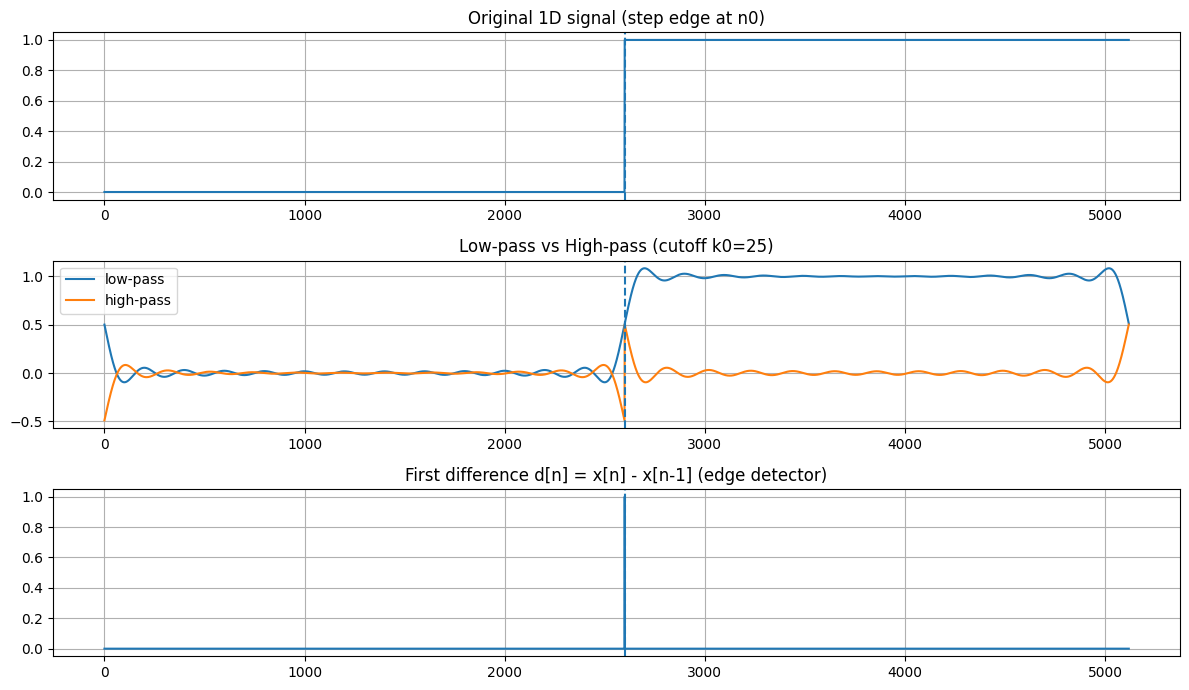

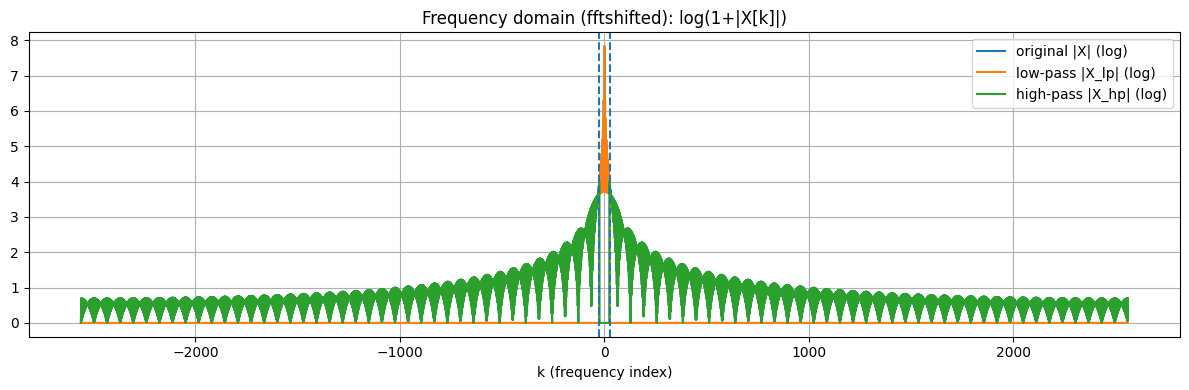

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Create a 1D signal with a single edge (step) ---
N = 5120
n = np.arange(N)
n0 = 2600

x = np.zeros(N)
x[n >= n0] = 1.0

# optional: add a slow trend + tiny noise to see what high-pass removes
x = x + 0.0*np.sin(2*np.pi*n/N * 3) + 0.0*np.random.randn(N)

# --- 2) FFT and shift so DC is centered ---
X = np.fft.fftshift(np.fft.fft(x))

# Frequency index axis: k = -N/2 ... N/2-1
k = np.arange(-N//2, N//2)

# --- 3) Choose cutoff and build masks ---
k0 = 25  # try 10, 25, 60

mask_lp = (np.abs(k) <= k0).astype(float)   # low-pass
mask_hp = (np.abs(k) >= k0).astype(float)   # high-pass

# Apply masks in shifted spectrum
X_lp = X * mask_lp
X_hp = X * mask_hp

# --- 4) Inverse FFT (undo shift first) ---
x_lp = np.real(np.fft.ifft(np.fft.ifftshift(X_lp)))
x_hp = np.real(np.fft.ifft(np.fft.ifftshift(X_hp)))

# --- 5) Classic 1D edge detector: first difference ---
d = np.zeros_like(x)
d[1:] = x[1:] - x[:-1]

# --- 6) Plots: time domain ---
fig = plt.figure(figsize=(12, 7))

ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(n, x)
ax1.axvline(n0, linestyle="--")
ax1.set_title("Original 1D signal (step edge at n0)")
ax1.grid(True)

ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(n, x_lp, label="low-pass")
ax2.plot(n, x_hp, label="high-pass")
ax2.axvline(n0, linestyle="--")
ax2.set_title(f"Low-pass vs High-pass (cutoff k0={k0})")
ax2.legend()
ax2.grid(True)

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(n, d)
ax3.axvline(n0, linestyle="--")
ax3.set_title("First difference d[n] = x[n] - x[n-1] (edge detector)")
ax3.grid(True)

plt.tight_layout()
plt.show()

# --- 7) Plots: frequency magnitude (log scale) ---
def logmag(z):
    return np.log1p(np.abs(z))

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(k, logmag(X), label="original |X| (log)")
ax.plot(k, logmag(X_lp), label="low-pass |X_lp| (log)")
ax.plot(k, logmag(X_hp), label="high-pass |X_hp| (log)")
ax.axvline(-k0, linestyle="--")
ax.axvline(k0, linestyle="--")
ax.set_title("Frequency domain (fftshifted): log(1+|X[k]|)")
ax.set_xlabel("k (frequency index)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
